In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Border, Side, Alignment, Font
from openpyxl.utils import get_column_letter
from scipy.stats import beta
from scipy.optimize import curve_fit



from matplotlib import font_manager
import matplotlib.pyplot as plt

font_legend = font_manager.FontProperties(family='Times New Roman', size=10)
font_tick = font_manager.FontProperties(family='Times New Roman', size=12)


# color1 = "#0072B2"   # Royal blue
# color2 = "#D55E00"   # Vermillion o

# color1 = "#1B3B6F"   # Deep navy
# color2 = "#33A1C9"   # Light cyan-blue

# color1 = "#1f78b4"
# color2 = "#b8860b"

# color1 = "#682E8A"   # Rich purple
# color2 = "#2AA198"   # Scientific teal

# color1 = "#2E7D32"
# color2 = "#C1602E"

# color1 = "#4B6EAF"
# color2 = "#444444"

# color1 = "#264653"
# color2 = "#2a9d8f"

# color1 = "#4C72B0"
# color2 = "#DD8452"

# color1 = "#20B2AA"
# color2 = "#D81B60"

color1 = "#1C92D2"
color2 = "#F7B500"

color3 = "#00A676"
color4 = "#8D3DAF"




In [ ]:
file_path = './KiwiFruit.xlsx'
xls = pd.ExcelFile(file_path, engine="openpyxl")
Report = pd.read_excel(xls, sheet_name = 'Report')
PredictedObservedBB = pd.read_excel(xls, sheet_name = 'PredictedObservedBB')
PredictedObservedBBHC = pd.read_excel(xls, sheet_name = 'PredictedObservedBBHC')
PredictedObservedFlowering = pd.read_excel(xls, sheet_name = 'PredictedObservedFloweringDOY')
PredictedObservedFloweringHC = pd.read_excel(xls, sheet_name = 'PredictedObservedFloweringDOYHC')


In [33]:
def EndoTempResponse(MeanT,a,b,c):
    return [a*T**2 + b*T + c if a*T**2 + b*T + c>=0 else 0 for T in MeanT ]

def wangengel(MinTemp,OptTemp,MaxTemp,RefTemp,T):
    RelEff = 0.0
    RelEffRefTemp = 1.0
    p = 0.0

    RelEff = np.zeros_like(T)
    RelEffRefTemp = np.zeros_like(T)

    mask1 = (T > MinTemp) & (T < MaxTemp)
    p = np.log(2.0) / np.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
    RelEff[mask1] = (2 * np.pow(T[mask1] - MinTemp, p) * np.pow(OptTemp - MinTemp, p) - np.pow(T[mask1] - MinTemp, 2 * p)) / np.pow(OptTemp - MinTemp, 2 * p)

    mask2 = (RefTemp > MinTemp) & (RefTemp < MaxTemp)
    p = np.log(2.0) / np.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
    RelEffRefTemp[mask2] = (2 * np.pow(RefTemp - MinTemp, p) * np.pow(OptTemp - MinTemp, p) - np.pow(RefTemp - MinTemp, 2 * p)) / np.pow(OptTemp - MinTemp, 2 * p)

    return RelEff / RelEffRefTemp

def MeanEndoResponse(MeanT,y_min,y_max,k,T_0):
    return y_min + y_max/(1+np.exp(-k*(MeanT-T_0)))

def asym_gauss(x, a, u, sigma_l, sigma_r):
    sigma = np.where(x < u, sigma_l, sigma_r)
    return 1 - a * np.exp(-(x - u)**2 / (2 * sigma**2))

def logistic(app_units, ideal_units, max_effect, steepness, elevation):
    return elevation + max_effect/(1 + np.exp(-steepness*(app_units - ideal_units)))

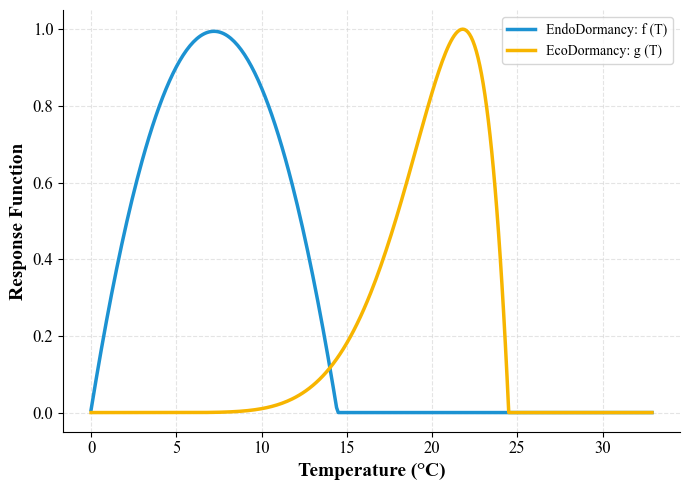

In [81]:
# Mean temperatures
MeanT = np.arange(0, 33, .1)    

a = -0.01898898919885883
b = 0.273859610005452
c = 0.006997020440018598
endoTempResponse = EndoTempResponse(MeanT,a,b,c)


# EcoDormancy model parameters
MinTemp = 3.79
OptTemp = 21.8
MaxTemp = 24.5
RefTemp = 21.8
ecoTempResponse = wangengel(MinTemp, OptTemp, MaxTemp, RefTemp, MeanT)

plt.figure(figsize=(7,5))

plt.plot(MeanT, endoTempResponse, label='EndoDormancy: f (T)', color=color1, linewidth=2.5)
plt.plot(MeanT, ecoTempResponse, label='EcoDormancy: g (T)', color=color2, linewidth=2.5)

plt.legend(prop=font_legend)

plt.xlabel("Temperature (°C)", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Response Function", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)

# for spine in plt.gca().spines.values():
#     spine.set_linewidth(1.2)

plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/ChillHeatTT.png", dpi=600, bbox_inches='tight')


plt.show()

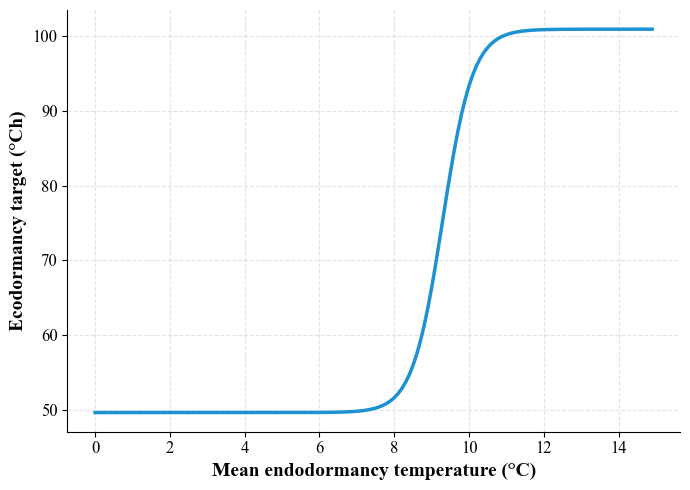

In [282]:
# Mean temperatures
MeanT = np.arange(0, 15, .1)  
Target = 101.29
y_min = 0.4901185445285534
y_max = 0.5063417939209804
k = 2.481340711095187
T_0 = 9.295011838785923

EcoTarget = Target*MeanEndoResponse(MeanT,y_min,y_max,k,T_0)

plt.figure(figsize=(7,5))
plt.plot(MeanT,EcoTarget, color=color1, linewidth=2.5)

# plt.legend(prop=font_legend)

plt.xlabel("Mean endodormancy temperature (°C)", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Ecodormancy target (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)

# for spine in plt.gca().spines.values():
#     spine.set_linewidth(1.2)

plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/HeatTarget.png", dpi=600, bbox_inches='tight')


plt.show()

C:\Users\HRANFS\AppData\Local\Temp\ipykernel_28008\3156628898.py:30: RuntimeWarning: overflow encountered in exp
  return elevation + max_effect/(1 + np.exp(-steepness*(app_units - ideal_units)))


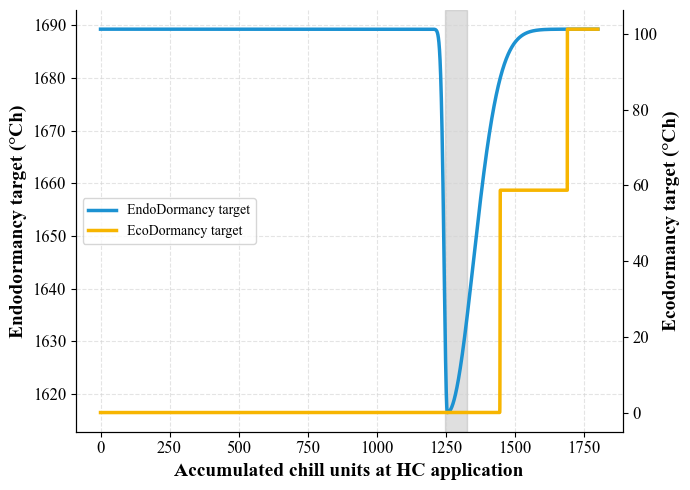

In [285]:
# Chill Units at HC
chillsAtHC = np.arange(0, 1800, .1)  
UntreatedEndoTarget = 1689.3
UntreatedEcoTarget = 101.29

# asymmetric gaussian for HCChillSensitivity
a = 0.04309999999999999 
u = 1255.1508275658016 
sigma_l = 11.751802909717238 
sigma_r = 94.29107329612533

HCChillSensitivity = UntreatedEndoTarget*asym_gauss(chillsAtHC,a,u,sigma_l, sigma_r)

# logistic for HCHeatSensitivity
ideal_units = 1445.77
max_effect = 0.58
steepness = 6.76
elevation = 0.00

HCHeatSensitivity = [UntreatedEcoTarget*logistic(unit, ideal_units, max_effect, steepness, elevation) if unit<=UntreatedEndoTarget else UntreatedEcoTarget for unit in chillsAtHC]


plt.figure(figsize=(7,5))

# --- PRIMARY AXIS (Left Y-axis) ---
ax1 = plt.gca()
ln1 = ax1.plot(chillsAtHC, HCChillSensitivity, 
               color=color1, linewidth=2.5, 
               label='EndoDormancy target')

ax1.set_xlabel("Accumulated chill units at HC application", 
               fontsize=14, fontweight="bold", font=font_tick)

ax1.set_ylabel("Endodormancy target (°Ch)", 
               fontsize=14, fontweight="bold", font=font_tick)

ax1.tick_params(axis='both', labelsize=12)
plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

ax1.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.spines['top'].set_visible(False)

# Shaded area with max HC effect
max_effect_locs = np.where(HCChillSensitivity<(np.max(HCChillSensitivity) - 0.75*(np.max(HCChillSensitivity)-np.min(HCChillSensitivity))))[0]
x0 = chillsAtHC[max_effect_locs[0]]
x1 = chillsAtHC[max_effect_locs[-1]]
ax1.axvspan(x0, x1, color='gray', alpha=0.25)

# --- SECONDARY AXIS (Right Y-axis) ---
ax2 = ax1.twinx()   # create right y-axis
ln2 = ax2.plot(chillsAtHC, HCHeatSensitivity, 
               color=color2, linewidth=2.5, 
               label='EcoDormancy target')

ax2.set_ylabel("Ecodormancy target (°Ch)", 
               fontsize=14, fontweight="bold", font=font_tick)

ax2.tick_params(axis='y', labelsize=12)
plt.yticks(fontproperties=font_tick)


# --- COMBINED LEGEND ---
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, prop=font_legend, loc='center left')

plt.gca().spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/HCresponse.png", dpi=600, bbox_inches='tight')
plt.show()


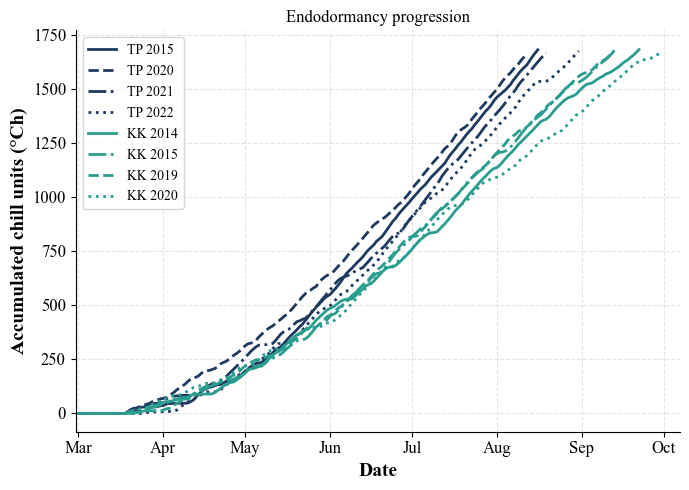

In [654]:
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
EcoDormancyProgressThroughPhase = Report['KiwiFruit.Phenology.EcoDormancy.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']
START_DOY=59


# SimulationName = HaywardBB2014Control (KK)
simulation28 = (Report['SimulationID'] == 28) & (Report['Clock.Today.Year'] == 2014)
# SimulationName = HaywardBB2019Untreatedcontrol (KK)
simulation17 = (Report['SimulationID'] == 17) & (Report['Clock.Today.Year'] == 2019)
# SimulationName = HaywardKKBBControl (KK)
simulation4 = (Report['SimulationID'] == 4) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HWBBRaw2020Control (KK)
simulation18 = (Report['SimulationID'] == 18) & (Report['Clock.Today.Year'] == 2020)

# SimulationName = HaywardTPBBCon1 (TP)
simulation2 = (Report['SimulationID'] == 2) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HW-Budbreak-TP2020Control (TP)
simulation22 = (Report['SimulationID'] == 22) & (Report['Clock.Today.Year'] == 2020)
# SimulationName = HWBBRawTP2021Control (TP)
simulation21 = (Report['SimulationID'] == 21) & (Report['Clock.Today.Year'] == 2021)
# SimulationName = HWBBTP2022Control (TP)
simulation27 = (Report['SimulationID'] == 27) & (Report['Clock.Today.Year'] == 2022)



mask28_endo = (DOY[simulation28] <= 265)
mask28_eco1  = (DOY[simulation28] <= 286) 
mask28_eco2  = (DOY[simulation28] >= 165)

mask17_endo = (DOY[simulation17] <= 256)
mask17_eco1  = (DOY[simulation17] <= 278) 
mask17_eco2  = (DOY[simulation17] >= 165)

mask4_endo = (DOY[simulation4] <= 257)
mask4_eco1  = (DOY[simulation4] <= 282) 
mask4_eco2  = (DOY[simulation4] >= 165)

mask2_endo = (DOY[simulation2] <= 228)
mask2_eco1  = (DOY[simulation2] <= 275) 
mask2_eco2  = (DOY[simulation2] >= 165)

mask22_endo = (DOY[simulation22] <= 224)
mask22_eco1  = (DOY[simulation22] <= 267) 
mask22_eco2  = (DOY[simulation22] >= 165)

mask18_endo = (DOY[simulation18] <= 273)
mask18_eco1  = (DOY[simulation18] <= 291) 
mask18_eco2  = (DOY[simulation18] >= 165)

mask21_endo = (DOY[simulation21] <= 231)
mask21_eco1  = (DOY[simulation21] <= 274) 
mask21_eco2  = (DOY[simulation21] >= 165)

mask27_endo = (DOY[simulation27] <= 243)
mask27_eco1  = (DOY[simulation27] <= 275) 
mask27_eco2  = (DOY[simulation27] >= 165)



EndoProgress28 = AccumulatedChilling[simulation28].copy()
EcoProgress28  = EcoDormancyProgressThroughPhase[simulation28].copy()
EndoProgress17 = AccumulatedChilling[simulation17].copy()
EcoProgress17  = EcoDormancyProgressThroughPhase[simulation17].copy()
EndoProgress4 = AccumulatedChilling[simulation4].copy()
EcoProgress4  = EcoDormancyProgressThroughPhase[simulation4].copy()
EndoProgress2 = AccumulatedChilling[simulation2].copy()
EcoProgress2  = EcoDormancyProgressThroughPhase[simulation2].copy()
EndoProgress22 = AccumulatedChilling[simulation22].copy()
EcoProgress22  = EcoDormancyProgressThroughPhase[simulation22].copy()
EndoProgress18 = AccumulatedChilling[simulation18].copy()
EcoProgress18  = EcoDormancyProgressThroughPhase[simulation18].copy()
EndoProgress21 = AccumulatedChilling[simulation21].copy()
EcoProgress21  = EcoDormancyProgressThroughPhase[simulation21].copy()
EndoProgress27 = AccumulatedChilling[simulation27].copy()
EcoProgress27  = EcoDormancyProgressThroughPhase[simulation27].copy()

# Set values outside of mask to zero
EcoProgress28[~mask28_eco2]   = 0
EcoProgress17[~mask17_eco2]   = 0
EcoProgress4[~mask4_eco2]   = 0
EcoProgress2[~mask2_eco2]   = 0
EcoProgress22[~mask22_eco2]   = 0
EcoProgress18[~mask18_eco2]   = 0
EcoProgress21[~mask21_eco2]   = 0
EcoProgress27[~mask27_eco2]   = 0


plt.figure(figsize=(7,5))

plt.plot(DOY[simulation2][mask2_endo], EndoProgress2[mask2_endo], color='#1F3A5F', linewidth=2, linestyle='-', label='TP 2015')
# plt.plot(DOY[simulation2][mask2_eco1], EcoProgress2[mask2_eco1], color='#1F3A5F', linewidth=2, linestyle='-', label='TP 2015')

plt.plot(DOY[simulation22][mask22_endo], EndoProgress22[mask22_endo], color='#1F3A5F', linewidth=2, linestyle='--',   label='TP 2020')
# plt.plot(DOY[simulation22][mask22_eco1], EcoProgress22[mask22_eco1], color='#1F3A5F', linewidth=2, linestyle='--',   label='TP 2020')

plt.plot(DOY[simulation21][mask21_endo], EndoProgress21[mask21_endo], color='#1F3A5F', linewidth=2, linestyle='-.',  label='TP 2021')
# plt.plot(DOY[simulation21][mask21_eco1], EcoProgress21[mask21_eco1], color='#1F3A5F', linewidth=2, linestyle='-.',  label='TP 2021'')

plt.plot(DOY[simulation27][mask27_endo], EndoProgress27[mask27_endo], color='#1F3A5F', linewidth=2, linestyle=':',   label='TP 2022')
# plt.plot(DOY[simulation27][mask27_eco1], EcoProgress27[mask27_eco1], color='#1F3A5F', linewidth=2, linestyle=':',   label='TP 2022')


plt.plot(DOY[simulation28][mask28_endo], EndoProgress28[mask28_endo], color='#2A9D8F', linewidth=2, linestyle='-', label='KK 2014')
# plt.plot(DOY[simulation28][mask28_eco1], EcoProgress28[mask28_eco1], color='#2A9D8F', linewidth=2, linestyle='-', label='KK 2014')

plt.plot(DOY[simulation4][mask4_endo], EndoProgress4[mask4_endo], color='#2A9D8F', linewidth=2, linestyle='-.', label='KK 2015')
# plt.plot(DOY[simulation4][mask4_eco1], EcoProgress4[mask4_eco1], color='#2A9D8F', linewidth=2, linestyle='-.', label='KK 2015')

plt.plot(DOY[simulation17][mask17_endo], EndoProgress17[mask17_endo], color='#2A9D8F', linewidth=2, linestyle='--', label='KK 2019')
# plt.plot(DOY[simulation17][mask17_eco1], EcoProgress17[mask17_eco1], color='#2A9D8F', linewidth=2, linestyle='--', label='KK 2019)

plt.plot(DOY[simulation18][mask18_endo], EndoProgress18[mask18_endo], color='#2A9D8F', linewidth=2, linestyle=':',  label='KK 2020')
# plt.plot(DOY[simulation18][mask18_eco1], EcoProgress18[mask18_eco1], color='#2A9D8F', linewidth=2, linestyle=':',  label='KK 2020')



plt.legend(prop=font_legend)
plt.title("Endodormancy progression", fontsize=14, fontweight="bold", font=font_tick)
plt.xlabel("Date", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Accumulated chill units (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
# Month-start ticks
month_start_mask = Dates[simulation28].dt.day == 1
xticks = Dates[simulation28].dt.dayofyear[month_start_mask]
xtick_labels = Dates[simulation28].dt.strftime('%b')[month_start_mask]
#  KEEP ONLY ticks within x-limits
mask_in_range = (xticks >= 59) & (xticks <= 280)
xticks = xticks[mask_in_range]
xtick_labels = xtick_labels[mask_in_range]


plt.xlim(59,280)
plt.xticks(xticks, xtick_labels, fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulationsEndoNatural.png", dpi=600, bbox_inches='tight')


plt.show()

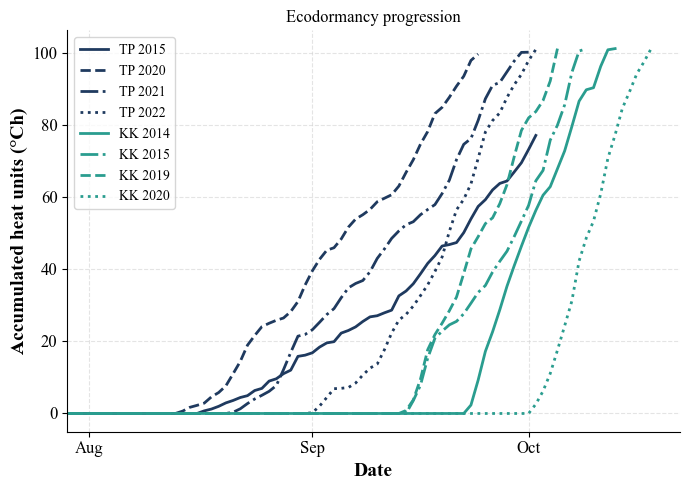

In [655]:
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
EcoDormancyProgressThroughPhase = Report['KiwiFruit.Phenology.EcoDormancy.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']
START_DOY=59


# SimulationName = HaywardBB2014Control (KK)
simulation28 = (Report['SimulationID'] == 28) & (Report['Clock.Today.Year'] == 2014)
# SimulationName = HaywardBB2019Untreatedcontrol (KK)
simulation17 = (Report['SimulationID'] == 17) & (Report['Clock.Today.Year'] == 2019)
# SimulationName = HaywardKKBBControl (KK)
simulation4 = (Report['SimulationID'] == 4) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HWBBRaw2020Control (KK)
simulation18 = (Report['SimulationID'] == 18) & (Report['Clock.Today.Year'] == 2020)

# SimulationName = HaywardTPBBCon1 (TP)
simulation2 = (Report['SimulationID'] == 2) & (Report['Clock.Today.Year'] == 2015)
# SimulationName = HW-Budbreak-TP2020Control (TP)
simulation22 = (Report['SimulationID'] == 22) & (Report['Clock.Today.Year'] == 2020)
# SimulationName = HWBBRawTP2021Control (TP)
simulation21 = (Report['SimulationID'] == 21) & (Report['Clock.Today.Year'] == 2021)
# SimulationName = HWBBTP2022Control (TP)
simulation27 = (Report['SimulationID'] == 27) & (Report['Clock.Today.Year'] == 2022)



mask28_endo = (DOY[simulation28] <= 265)
mask28_eco1  = (DOY[simulation28] <= 286) 
mask28_eco2  = (DOY[simulation28] >= 165)

mask17_endo = (DOY[simulation17] <= 256)
mask17_eco1  = (DOY[simulation17] <= 278) 
mask17_eco2  = (DOY[simulation17] >= 165)

mask4_endo = (DOY[simulation4] <= 257)
mask4_eco1  = (DOY[simulation4] <= 282) 
mask4_eco2  = (DOY[simulation4] >= 165)

mask2_endo = (DOY[simulation2] <= 228)
mask2_eco1  = (DOY[simulation2] <= 275) 
mask2_eco2  = (DOY[simulation2] >= 165)

mask22_endo = (DOY[simulation22] <= 224)
mask22_eco1  = (DOY[simulation22] <= 267) 
mask22_eco2  = (DOY[simulation22] >= 165)

mask18_endo = (DOY[simulation18] <= 273)
mask18_eco1  = (DOY[simulation18] <= 291) 
mask18_eco2  = (DOY[simulation18] >= 165)

mask21_endo = (DOY[simulation21] <= 231)
mask21_eco1  = (DOY[simulation21] <= 274) 
mask21_eco2  = (DOY[simulation21] >= 165)

mask27_endo = (DOY[simulation27] <= 243)
mask27_eco1  = (DOY[simulation27] <= 275) 
mask27_eco2  = (DOY[simulation27] >= 165)



EndoProgress28 = AccumulatedChilling[simulation28].copy()
EcoProgress28  = EcoDormancyProgressThroughPhase[simulation28].copy()
EndoProgress17 = AccumulatedChilling[simulation17].copy()
EcoProgress17  = EcoDormancyProgressThroughPhase[simulation17].copy()
EndoProgress4 = AccumulatedChilling[simulation4].copy()
EcoProgress4  = EcoDormancyProgressThroughPhase[simulation4].copy()
EndoProgress2 = AccumulatedChilling[simulation2].copy()
EcoProgress2  = EcoDormancyProgressThroughPhase[simulation2].copy()
EndoProgress22 = AccumulatedChilling[simulation22].copy()
EcoProgress22  = EcoDormancyProgressThroughPhase[simulation22].copy()
EndoProgress18 = AccumulatedChilling[simulation18].copy()
EcoProgress18  = EcoDormancyProgressThroughPhase[simulation18].copy()
EndoProgress21 = AccumulatedChilling[simulation21].copy()
EcoProgress21  = EcoDormancyProgressThroughPhase[simulation21].copy()
EndoProgress27 = AccumulatedChilling[simulation27].copy()
EcoProgress27  = EcoDormancyProgressThroughPhase[simulation27].copy()

# Set values outside of mask to zero
EcoProgress28[~mask28_eco2]   = 0
EcoProgress17[~mask17_eco2]   = 0
EcoProgress4[~mask4_eco2]   = 0
EcoProgress2[~mask2_eco2]   = 0
EcoProgress22[~mask22_eco2]   = 0
EcoProgress18[~mask18_eco2]   = 0
EcoProgress21[~mask21_eco2]   = 0
EcoProgress27[~mask27_eco2]   = 0


plt.figure(figsize=(7,5))

plt.plot(DOY[simulation2][mask2_eco1], EcoProgress2[mask2_eco1], color='#1F3A5F', linewidth=2, linestyle='-', label='TP 2015')

plt.plot(DOY[simulation22][mask22_eco1], EcoProgress22[mask22_eco1], color='#1F3A5F', linewidth=2, linestyle='--',   label='TP 2020')

plt.plot(DOY[simulation21][mask21_eco1], EcoProgress21[mask21_eco1], color='#1F3A5F', linewidth=2, linestyle='-.',  label='TP 2021')

plt.plot(DOY[simulation27][mask27_eco1], EcoProgress27[mask27_eco1], color='#1F3A5F', linewidth=2, linestyle=':',   label='TP 2022')


plt.plot(DOY[simulation28][mask28_eco1], EcoProgress28[mask28_eco1], color='#2A9D8F', linewidth=2, linestyle='-', label='KK 2014')

plt.plot(DOY[simulation4][mask4_eco1], EcoProgress4[mask4_eco1], color='#2A9D8F', linewidth=2, linestyle='-.', label='KK 2015')

plt.plot(DOY[simulation17][mask17_eco1], EcoProgress17[mask17_eco1], color='#2A9D8F', linewidth=2, linestyle='--', label='KK 2019')

plt.plot(DOY[simulation18][mask18_eco1], EcoProgress18[mask18_eco1], color='#2A9D8F', linewidth=2, linestyle=':',  label='KK 2020')



plt.legend(prop=font_legend)
plt.title('Ecodormancy progression', font=font_tick)
plt.xlabel("Date", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Accumulated heat units (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
# Month-start ticks
month_start_mask = Dates[simulation28].dt.day == 1
xticks = Dates[simulation28].dt.dayofyear[month_start_mask]
xtick_labels = Dates[simulation28].dt.strftime('%b')[month_start_mask]
#  KEEP ONLY ticks within x-limits
mask_in_range = (xticks >= 210) & (xticks <= 295)
xticks = xticks[mask_in_range]
xtick_labels = xtick_labels[mask_in_range]


plt.xlim(210,295)
plt.xticks(xticks, xtick_labels, fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulationsEndoNatural.png", dpi=600, bbox_inches='tight')


plt.show()

In [645]:
pd.to_datetime('2019-8-16').day_of_year #- pd.to_datetime('2022-09-21').day_of_year

228

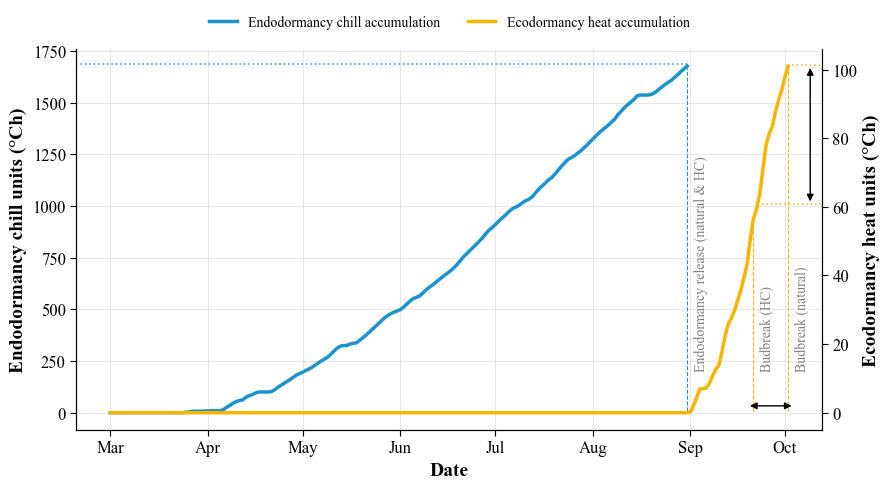

In [515]:
AccumulatedChilling = Report['KiwiFruit.Phenology.AccumulatedChilling']
EcoDormancyProgressThroughPhase = Report['KiwiFruit.Phenology.EcoDormancy.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']

START_DOY = 59
# SimulationName = HWBBTP2022Control
simulation27 = (Report['SimulationID'] == 27) & (Report['Clock.Today.Year'] == 2022)
# SimulationName = HWBBTP2022HC225
simulation71 = (Report['SimulationID'] == 71) & (Report['Clock.Today.Year'] == 2022)
x = DOY[simulation27][START_DOY:]
Dates = pd.to_datetime(Dates[simulation27][START_DOY:])

mask_endo27 = (DOY[simulation27] <= 243)
mask_eco27a  = (DOY[simulation27] >= 165)
mask_eco27b  = (DOY[simulation27] <= 275) 

EndoProgress27 = AccumulatedChilling[simulation27][START_DOY:].copy()
EcoProgress27  = EcoDormancyProgressThroughPhase[simulation27][START_DOY:].copy()

# EndoProgress71 = AccumulatedChilling[simulation71][START_DOY:].copy()
# EcoProgress71  = EcoDormancyProgressThroughPhase[simulation71][START_DOY:].copy()

# Set values outside of mask to zero or nan
EndoPlot = EndoProgress27.copy()
EndoPlot[~mask_endo27] = np.nan

EcoPlot = EcoProgress27.copy()
EcoPlot[~mask_eco27a] = 0
EcoPlot[~mask_eco27b] = np.nan

Dates[~mask_eco27b] = np.nan

fig, ax = plt.subplots(figsize=(9,5))

# ---- Left axis: Endodormancy ----
ln1, = ax.plot(
    x, EndoPlot, color=color1, linewidth=2.5,
    label='Endodormancy chill accumulation'
)

ax.set_ylabel(
    "Endodormancy chill units (°Ch)",
    fontsize=14, fontweight="bold", fontproperties=font_tick
)

# Endo target
ax.axhline(
    1689, xmax=0.82,
    color=color1, linestyle=':', linewidth=1.2, alpha=0.8
)

# ---- Right axis: Ecodormancy ----
ax2 = ax.twinx()

ln2, = ax2.plot(
    x, EcoPlot, color=color2, linewidth=2.5,
    label='Ecodormancy heat accumulation'
)

ax2.set_ylabel(
    "Ecodormancy heat units (°Ch)",
    fontsize=14, fontweight="bold", fontproperties=font_tick
)

# Eco targets
ax2.axhline(
    101.29, xmin=0.96, xmax=1,
    color=color2, linestyle=':', linewidth=1.2, alpha=0.8
)
ax2.axhline(
    60.78, xmin=0.92, xmax=1,
    color=color2, linestyle=':', linewidth=1.2, alpha=0.8
)

# ---- Shared vertical event markers (draw ONLY on ax) ----
# ax.axvline(243, ymin=0.05, ymax=1, color='gray', linestyle='--', linewidth=0.8)
ax.text(245, 200, "Endodormancy release (natural & HC)", color='gray', rotation=90, va='bottom', fontproperties=font_legend)
ax.text(266, 200, "Budbreak (HC)", color='gray', rotation=90, va='bottom', fontproperties=font_legend)
ax.text(277, 200, "Budbreak (natural)", color='gray', rotation=90, va='bottom', fontproperties=font_legend)

ax.axvline(275, ymin=0.05, ymax=0.95, color=color2, linestyle='--', linewidth=0.8)
ax.axvline(264, ymin=0.05, ymax=0.55, color=color2, linestyle='--', linewidth=0.8)
ax.axvline(243, ymin=0.05, ymax=0.95, color=color1, linestyle='--', linewidth=0.8)


# ---- Arrow annotation ----
ax2.annotate(
    "",
    xy=(277, 2),
    xytext=(262, 2),
    arrowprops=dict(
        arrowstyle="<|-|>",
        linewidth=1,
        color="black"
    )
)
ax2.annotate(
    "",
    xy=(282, 60.78),
    xytext=(282, 101.29),
    arrowprops=dict(
        arrowstyle="<|-|>",
        linewidth=1,
        color="black"
    )
)

# ---- X axis ----
ax.set_xlabel(
    "Date",
    fontsize=14, fontweight="bold", fontproperties=font_tick
)

month_start_mask = Dates.dt.day == 1
xticks = Dates.dt.dayofyear[month_start_mask]
xtick_labels = Dates.dt.strftime('%b')[month_start_mask]

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontproperties=font_tick)

for label in ax.get_yticklabels():
    label.set_fontproperties(font_tick)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_tick)


# ---- Legend (combined, outside, compact) ----
ax.legend(
    handles=[ln1, ln2],
    prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

# ---- Grid & aesthetics ----
# ax.grid(axis='x', linewidth=0.6, color='lightgray', alpha=0.6)
ax.grid(linewidth=0.6, color='lightgray', alpha=0.6)


ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax.tick_params(width=0.8, length=4)
ax2.tick_params(width=0.8, length=4)


plt.tight_layout()    
plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulation71BB.png", dpi=600, bbox_inches='tight')

plt.show()

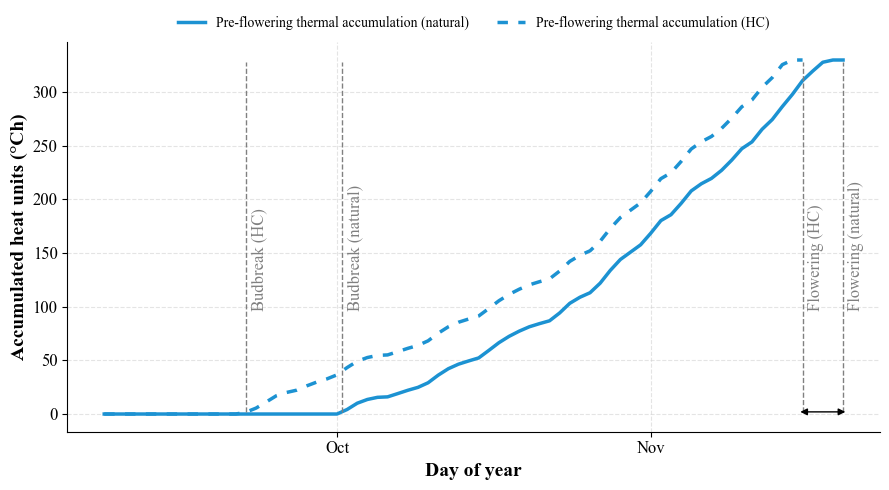

In [516]:
# EarlyLeafProgressThroughPhase
EarlyLeafProgressThroughPhase = Report['KiwiFruit.Phenology.EarlyLeaf.ProgressThroughPhase']
DOY = Report['Clock.Today.DayOfYear']
Dates = Report['Clock.Today']
START_DOY = 250

# SimulationName = HWBBTP2022Control
simulation27 = (Report['SimulationID'] == 27) & (Report['Clock.Today.Year'] == 2022)
# SimulationName = HWBBTP2022HC225
simulation71 = (Report['SimulationID'] == 71) & (Report['Clock.Today.Year'] == 2022)

x = DOY[simulation27][START_DOY:]
Dates = pd.to_datetime(Dates[simulation27][START_DOY:])

EarlyLeafProgressThroughPhase27  = EarlyLeafProgressThroughPhase[simulation27].copy()
EarlyLeafProgressThroughPhase71  = EarlyLeafProgressThroughPhase[simulation71].copy()

mask_27a  = (DOY[simulation27] >= 165)
mask_27b  = (DOY[simulation27] <= 324) 

mask_71a  = (DOY[simulation71] >= 165)
mask_71b  = (DOY[simulation71] <= 320) 

# Set values outside of mask to zero
EarlyLeafProgressThroughPhase27[~mask_27a]   = 0
EarlyLeafProgressThroughPhase71[~mask_71a]   = 0

Dates[~mask_27b] = np.nan

plt.figure(figsize=(9,5))

plt.plot(DOY[simulation27][mask_27b][250:], EarlyLeafProgressThroughPhase27[mask_27b][250:], color=color1, linewidth=2.5, label='Pre‑flowering thermal accumulation (natural)')
plt.plot(DOY[simulation71][mask_71b][250:], EarlyLeafProgressThroughPhase71[mask_71b][250:], color=color1, dashes=(3, 3), linewidth=2.5, label='Pre‑flowering thermal accumulation (HC)')

plt.axvline(x=324, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(324+.5, 100, "Flowering (natural)", color='gray', rotation=90, fontproperties=font_tick)

plt.axvline(x=320, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(320+.5, 100, "Flowering (HC)", color='gray', rotation=90, fontproperties=font_tick)

plt.axvline(x=274.5, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(274.5+.5, 100, "Budbreak (natural)", color='gray', rotation=90, fontproperties=font_tick)

plt.axvline(x=265, ymin=.05, ymax=0.95, color='gray', linestyle='--', linewidth=1)
plt.text(265+.5, 100, "Budbreak (HC)", color='gray', rotation=90, fontproperties=font_tick)

# ---- Arrow annotation ----
# horizontal bidirecional arrow
plt.annotate(
    "",
    xy=(324.5, 2),
    xytext=(319.5, 2),
    arrowprops=dict(
        arrowstyle="<|-|>",
        linewidth=1,
        color="black"
    )
)


plt.legend(prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2)

plt.xlabel("Day of year", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Accumulated heat units (°Ch)", fontsize=14, fontweight="bold", font=font_tick)

# Tick fonts
month_start_mask = Dates.dt.day == 1
xticks = Dates.dt.dayofyear[month_start_mask]
xtick_labels = Dates.dt.strftime('%b')[month_start_mask]

plt.xticks(xticks)
plt.xticks(xticks, xtick_labels, fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/simulation27and71Flwring.png", dpi=600, bbox_inches='tight')


plt.show()

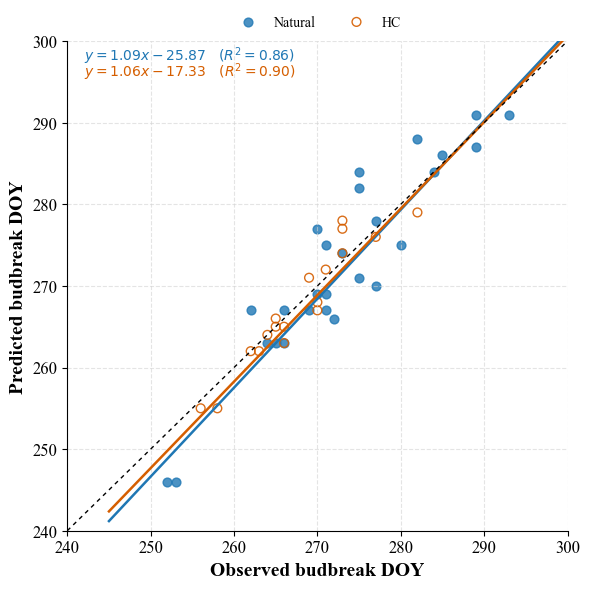

In [657]:
# BudBurstDOY
PredictedBudBurstDOY = PredictedObservedBB['Predicted.KiwiFruit.Phenology.BudBurstDOY']
ObservedBudBurstDOY = PredictedObservedBB['Observed.KiwiFruit.Phenology.BudBurstDOY']

PredictedBudBurstDOYHC = PredictedObservedBBHC['Predicted.KiwiFruit.Phenology.BudBurstDOY']
ObservedBudBurstDOYHC = PredictedObservedBBHC['Observed.KiwiFruit.Phenology.BudBurstDOY']

# Regressions
RegNatural = 1.09*np.array([245,300])-25.87
RegHC = 1.06*np.array([245,300])-17.33

plt.figure(figsize=(6,6))

plt.scatter(ObservedBudBurstDOY,PredictedBudBurstDOY,
           color="#1f77b4", edgecolor="#1f77b4",
           alpha=0.8, s=40, label="Natural")

plt.scatter(ObservedBudBurstDOYHC,PredictedBudBurstDOYHC,
           facecolors='none', edgecolors="#D55E00",
           alpha=0.9, s=40, label="HC")


plt.plot([245,300], RegNatural, color="#1f77b4", linewidth=1.8)
plt.plot([245,300], RegHC, color="#D55E00", linewidth=1.8)


# Natural regression equation
plt.text(
    242, 297,                        
    r"$y = 1.09x - 25.87 \quad (R^2 = 0.86)$",
    color="#1f77b4",
    fontsize=10,
    va="bottom",
)
# HC regression equation
plt.text(
    242, 295,                        
    r"$y = 1.06x - 17.33 \quad (R^2 = 0.90)$",
    color="#D55E00",
    fontsize=10,
    va="bottom"
)


plt.legend(prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2)

plt.xlabel("Observed budbreak DOY", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Predicted budbreak DOY", fontsize=14, fontweight="bold", font=font_tick)

# Set axis limits
plt.xlim(240, 300)
plt.ylim(240, 300)

plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# 1:1 line
plt.plot([240,300],[240,300],color='k',dashes=(3, 3), linewidth=1)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/PredvsObsBB.png", dpi=600, bbox_inches='tight')


plt.show()

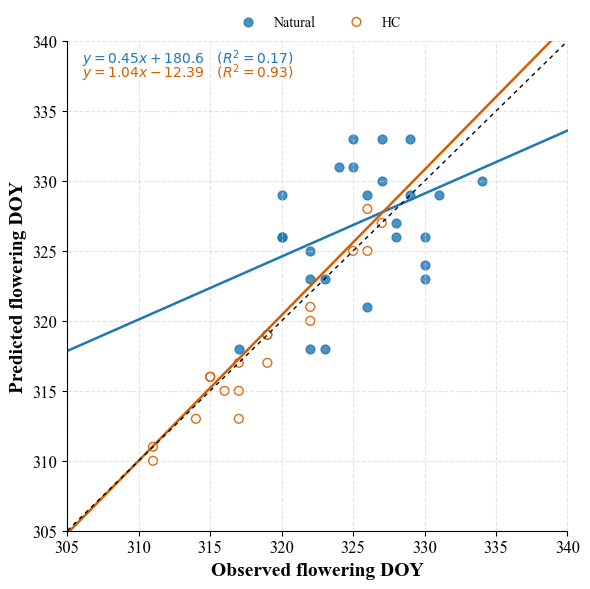

In [660]:
# FloweringDOY
PredictedBudFloweringDOY = PredictedObservedFlowering['Predicted.KiwiFruit.Phenology.FloweringDOY']
ObservedBudFloweringDOY = PredictedObservedFlowering['Observed.KiwiFruit.Phenology.FloweringDOY']

PredictedFloweringDOYHC = PredictedObservedFloweringHC['Predicted.KiwiFruit.Phenology.FloweringDOY']
ObservedFloweringDOYHC = PredictedObservedFloweringHC['Observed.KiwiFruit.Phenology.FloweringDOY']

# Regressions
axis_min=305
axis_max=340
RegNatural = 0.45*np.array([axis_min,axis_max])+180.60
RegHC = 1.04*np.array([axis_min,axis_max])-12.39

plt.figure(figsize=(6,6))

plt.scatter(ObservedBudFloweringDOY,PredictedBudFloweringDOY,
           color="#1f77b4", edgecolor="#1f77b4",
           alpha=0.8, s=40, label="Natural")

plt.scatter(ObservedFloweringDOYHC,PredictedFloweringDOYHC,
           facecolors='none', edgecolors="#D55E00",
           alpha=0.9, s=40, label="HC")


plt.plot([axis_min,axis_max], RegNatural, color="#1f77b4", linewidth=1.8)
plt.plot([axis_min,axis_max], RegHC, color="#D55E00", linewidth=1.8)


# Natural regression equation
plt.text(
    306, 338,                        
    r"$y = 0.45x + 180.6 \quad (R^2 = 0.17)$",
    color="#1f77b4",
    fontsize=10,
    va="bottom",
)
# HC regression equation
plt.text(
    306, 337,                        
    r"$y = 1.04x - 12.39 \quad (R^2 = 0.93)$",
    color="#D55E00",
    fontsize=10,
    va="bottom"
)


plt.legend(prop=font_legend,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2)

plt.xlabel("Observed flowering DOY", fontsize=14, fontweight="bold", font=font_tick)
plt.ylabel("Predicted flowering DOY", fontsize=14, fontweight="bold", font=font_tick)

# Set axis limits
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)

plt.xticks(fontproperties=font_tick)
plt.yticks(fontproperties=font_tick)

# 1:1 line
plt.plot([axis_min,axis_max],[axis_min,axis_max],color='k',dashes=(3, 3), linewidth=1)

# Change grid color and style
plt.grid(color="lightgray", linestyle="--", linewidth=0.8, alpha=0.6)


plt.tight_layout()    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("C:/Users/HRANFS/Documents/Hayward HC paper 2026/photo bin/PredvsObsFlwr.png", dpi=600, bbox_inches='tight')


plt.show()